# Chapter 8. Data Wrangling: Join, Combine, and Reshape

In [1]:
import pandas as pd
import numpy as np

## 8.2 Combining and Merging Datasets

- ***pandas.merge*** connect rows in DataFrames based on one or more keys. (*join* operation)
- ***pandas.concat*** concatenates or "stacks" together objects along an axis.
- The ***combine_first*** instance method enables splicing together overlapping data to fill in missing values in one object with values from another.

### Concatenating Along Axis

In [3]:
arr = np.arange(12).reshape((3,4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11]])

In [6]:
np.concatenate([arr,arr], axis=1) # axis=1 -> 열방향으로 붙이기

array([[ 0,  1,  2,  3,  0,  1,  2,  3],
       [ 4,  5,  6,  7,  4,  5,  6,  7],
       [ 8,  9, 10, 11,  8,  9, 10, 11]])

> - Ex1 : Three Series with no index overlap:

In [2]:
s1 = pd.Series([0,1], index=['a','b'])
s2 = pd.Series([2,3,4], index=['c','d','e'])
s3 = pd.Series([5,6], index=['f','g'])

In [3]:
pd.concat([s1,s2,s3])

a    0
b    1
c    2
d    3
e    4
f    5
g    6
dtype: int64

In [4]:
pd.concat([s1,s2,s3], axis=1)

,0,1,2
a,0.0,NaN,NaN
b,1.0,NaN,NaN
c,NaN,2.0,NaN
d,NaN,3.0,NaN
e,NaN,4.0,NaN
f,NaN,NaN,5.0
g,NaN,NaN,6.0


- By default, ***concat*** works along axis=0, **producing another Series**.
- If you pass ***axis=1***, the result will instead **be a DataFrame**:

> - Ex2 : index overlap이 있는 경우
> - 교집합 index만 표기하기 위해서는 ***join='inner'*** 옵션 부여 가능

In [12]:
s4 = pd.concat([s1, s3])
pd.concat([s1, s4], axis=1) # or axis='columns'

,0,1
a,0.0,0
b,1.0,1
f,NaN,5
g,NaN,6


In [13]:
pd.concat([s1, s4], axis=1, join='inner')

,0,1
a,0,0
b,1,1


> - Ex3 : Suppose instead you wanted to create a hierarchical index on the concatenation axis. To do this, use the ***keys*** argument:

In [15]:
result = pd.concat([s1, s1, s3], keys=['one','two','three'])
result

one    a    0
       b    1
two    a    0
       b    1
three  f    5
       g    6
dtype: int64

In [16]:
result.unstack()

,a,b,f,g
one,0.0,1.0,NaN,NaN
two,0.0,1.0,NaN,NaN
three,NaN,NaN,5.0,6.0


> - In the case of combining Series along ***axis=1***, the ***keys*** become the DataFrame column headers:

In [17]:
pd.concat([s1, s1, s3], axis='columns', keys=['one','two','three'])

,one,two,three
a,0.0,0.0,NaN
b,1.0,1.0,NaN
f,NaN,NaN,5.0
g,NaN,NaN,6.0


> - The same logic extends to DataFrame objects:

In [19]:
df1 = pd.DataFrame(np.arange(6).reshape((3,2)), index=['a','b','c'], columns=['one','two'])
df1

,one,two
a,0,1
b,2,3
c,4,5


In [22]:
df2 = pd.DataFrame(5+np.arange(4).reshape(2,2), index=['a','c'], columns=['three','four'])
df2

,three,four
a,5,6
c,7,8


In [24]:
pd.concat([df1,df2], axis='columns', keys=['level1','level2'])
# pd.concat({'level1':df1, 'level2':df2}, axis='columns')

level1     level2     
     one two  three four
a      0   1    5.0  6.0
b      2   3    NaN  NaN
c      4   5    7.0  8.0

> - We can name the created axis levels with the ***names*** argument:
> - pd.concat([df1, df2], axis='columns', keys=['level1','level2], names=['upper','lower])

> - A last consideration concerns DataFrames in which the row index does not contain any relevant data:

In [25]:
df1 = pd.DataFrame(np.random.randn(3,4), columns=['a','b','c','d'])
df2 = pd.DataFrame(np.random.randn(2,3), columns=['b','d','a'])

In [26]:
pd.concat([df1, df2])

,a,b,c,d
0,0.415979,-0.253018,0.470863,0.232945
1,-0.677421,0.907484,1.245876,-0.099873
2,0.723761,-1.544390,-0.630266,-0.778932
0,-0.425972,-0.034694,NaN,0.246326
1,0.341255,-1.314025,NaN,0.142731


In [27]:
pd.concat([df1, df2], ignore_index=True)

,a,b,c,d
0,0.415979,-0.253018,0.470863,0.232945
1,-0.677421,0.907484,1.245876,-0.099873
2,0.723761,-1.544390,-0.630266,-0.778932
3,-0.425972,-0.034694,NaN,0.246326
4,0.341255,-1.314025,NaN,0.142731


> 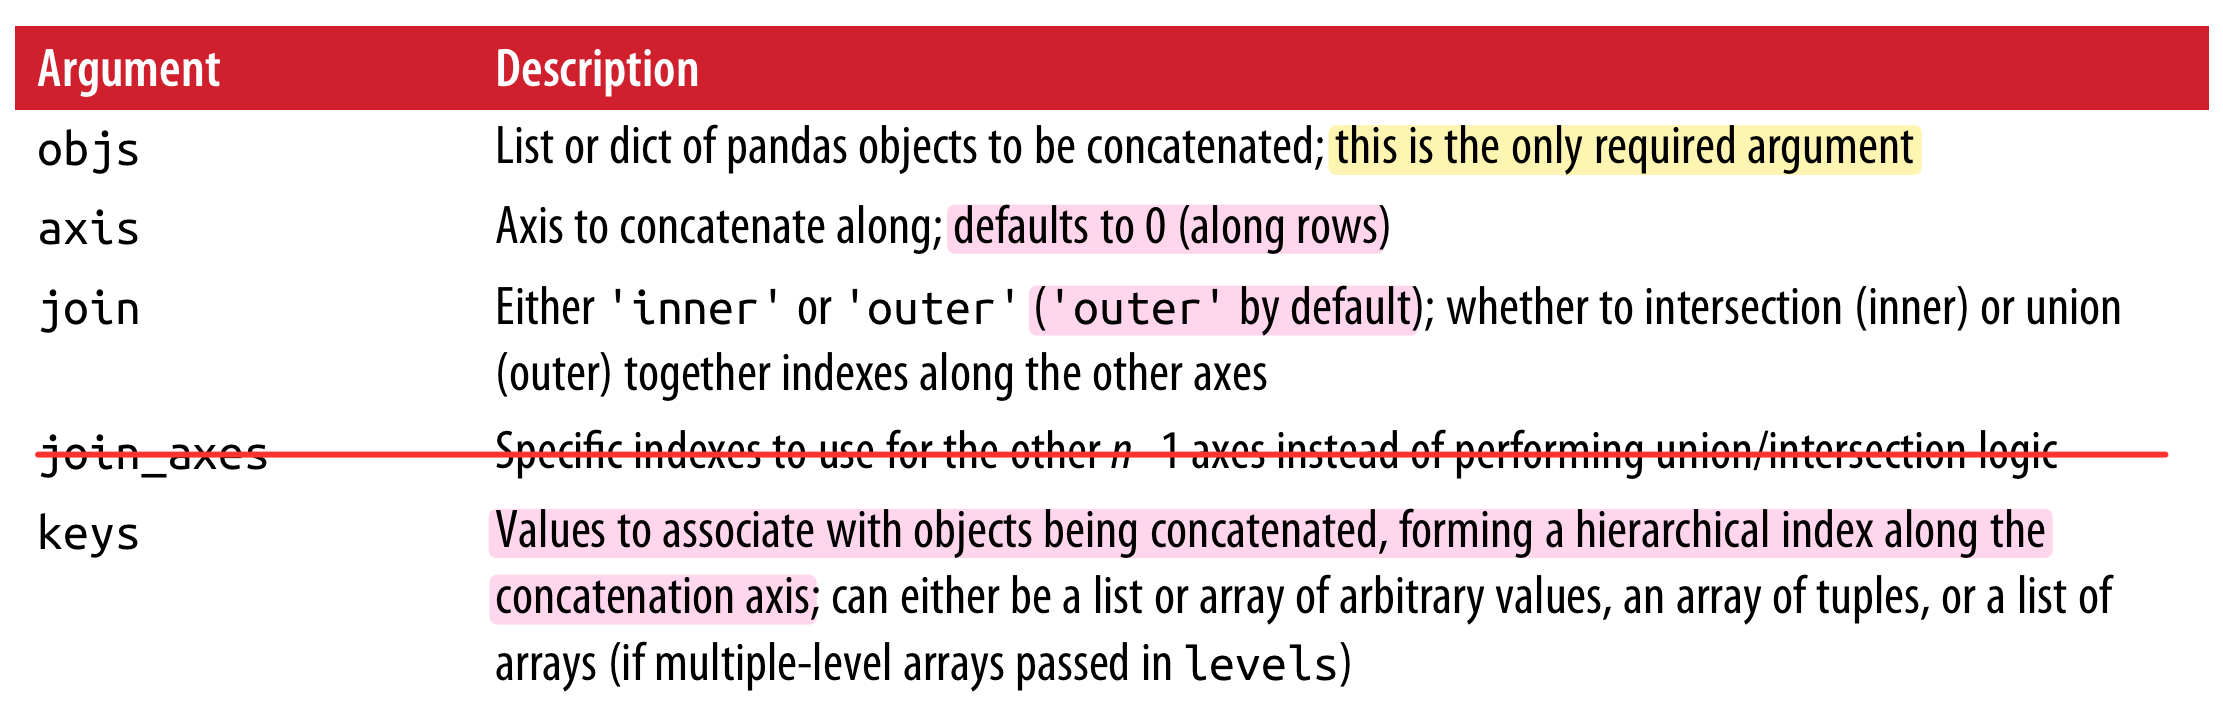
> 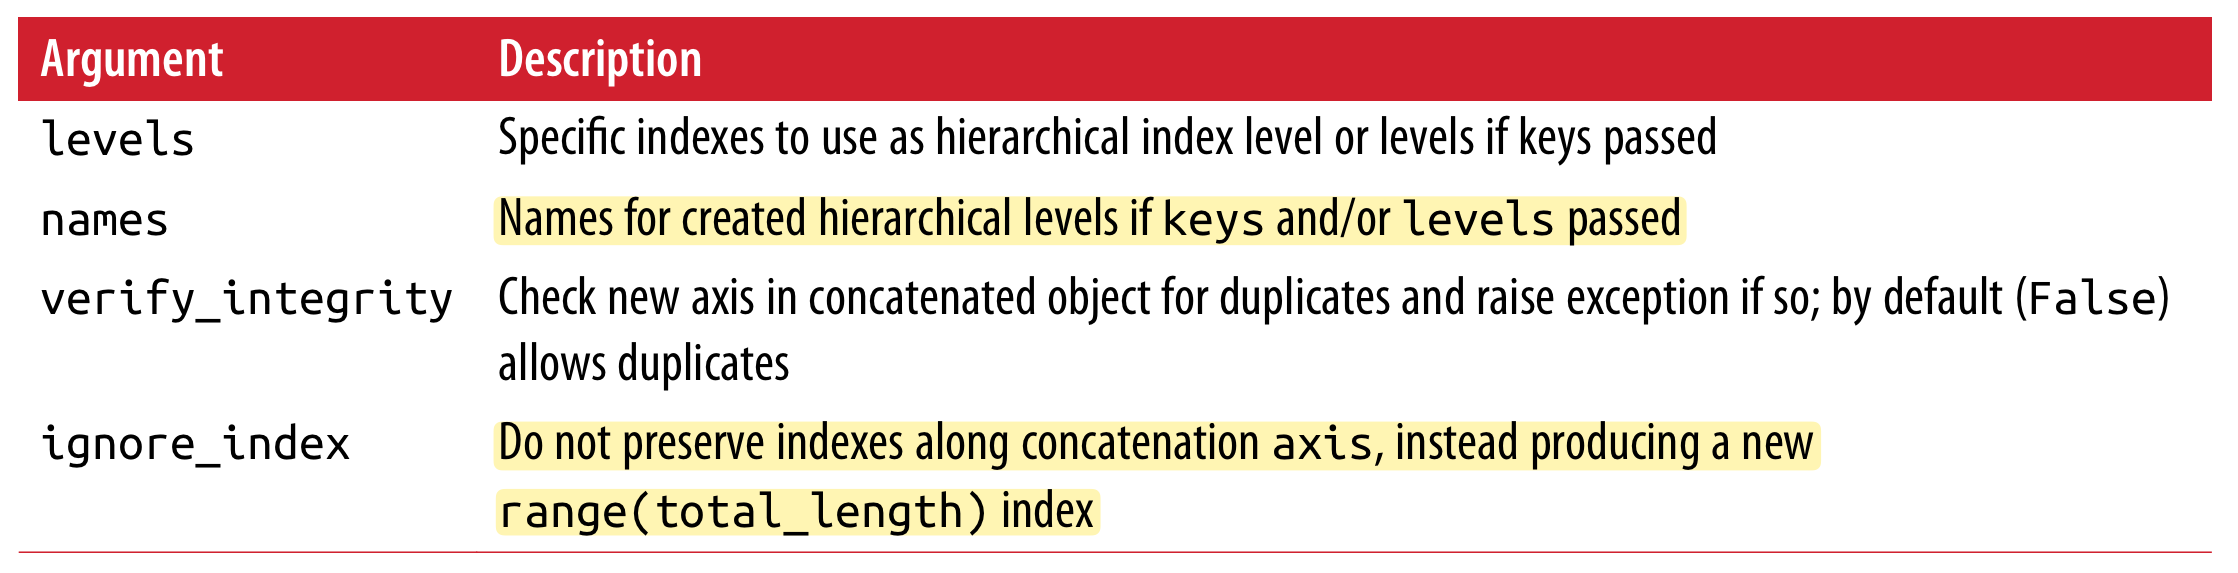

### Combining Data with Overlap

In [11]:
a = pd.Series([np.nan, 2.5, np.nan, 3.5, 4.5, np.nan], 
              index=['f','e','d','c','b','a'])
a

f    NaN
e    2.5
d    NaN
c    3.5
b    4.5
a    NaN
dtype: float64

In [8]:
b = pd.Series(np.arange(len(a), dtype=np.float64),
              index=['f','e','d','c','b','a'])
b[-1] = np.nan

In [4]:
np.where(pd.isnull(a), b, a)

array([0. , 2.5, 2. , 3.5, 4.5, nan])

> - self.combine_first(other) // other의 값으로 self(df)의 NaN 값을 덮어쓰는 메서드
> - "patching" missing data in the calling object with data from the object you pass: 

In [5]:
# for Series
b[:-2].combine_first(a[2:])

a    NaN
b    4.5
c    3.0
d    2.0
e    1.0
f    0.0
dtype: float64

In [6]:
# for DataFrame
df1 = pd.DataFrame({'a':[1,np.nan,5,np.nan],
                    'b':[np.nan,2,np.nan,6], 
                    'c':range(2,18,4)})
df1

,a,b,c
0,1.0,NaN,2
1,NaN,2.0,6
2,5.0,NaN,10
3,NaN,6.0,14


In [21]:
df2 =  pd.DataFrame({'a':[5,4,np.nan,3,7],
                     'b':[np.nan,3,4,6,8]})
df2

,a,b
0,5.0,NaN
1,4.0,3.0
2,NaN,4.0
3,3.0,6.0
4,7.0,8.0


In [22]:
df1.combine_first(df2)

,a,b,c
0,1.0,NaN,2.0
1,4.0,2.0,6.0
2,5.0,4.0,10.0
3,3.0,6.0,14.0
4,7.0,8.0,NaN
